# 12.4.1 一维扩散与边界

## 学习目标与先修知识

由邻格交换建立有限差分（finite difference）并检查质量与步长。

先修：11.2 无向交换与守恒；2.4 显式数值格式；中学二阶差分直觉。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

细胞沿一维组织排列，相邻位置交换物质。怎样把相邻收支（mass balance）写成空间变化，并防止数值步长把浓度（concentration）算成负数？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

三个格子中间放2 U，两侧为0；写出中央与两邻格的一步变化。

In [2]:
print('三格 [0,2,0]、α=.25 → [0.5,1,0.5]；总和仍为2。')

三格 [0,2,0]、α=.25 → [0.5,1,0.5]；总和仍为2。


## 模型假设

等距网格、常扩散系数（diffusion coefficient）、无反应与外部通量；周期边界（periodic boundary）首尾相接，无通量边界（no-flux boundary）采用单元中心守恒离散：端点格只有域内邻居，跨边界通量为0；代码中越界邻居取端点自身。内点使用中心差分（central difference）和显式 Euler，浓度单位按每格同体积的教学量处理；这不等同于节点中心的镜像幽灵点格式。

## 数学解释与推导

连续式 $\partial_t c=D\partial_{xx}c$ 中 $\partial_{xx}$ 描述局部曲率。令 $\alpha=D\Delta t/\Delta x^2$，离散为 $c_i^{t+1}=(1-2\alpha)c_i^t+\alpha c_{i-1}^t+\alpha c_{i+1}^t$。在本节的一维纯扩散格式中 $0\le\alpha\le1/2$ 保证非负权重；无通量左端实际更新为 $c_0^{t+1}=c_0^t+\alpha(c_1^t-c_0^t)$，没有跨界边。周期与此单元中心无通量格式的相邻交换都成对抵消，离散总和守恒。加入反应后须另核对时间尺度（time scale）和正性。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def diffuse_1d(values, diffusivity, dx, dt, steps, boundary):
    """Forward Euler with periodic or reflecting zero-flux endpoint neighbors."""
    current = list(map(float, values))
    history = [current.copy()]
    n = len(current)
    alpha = diffusivity * dt / dx**2
    for _ in range(steps):
        following = []
        for i, value in enumerate(current):
            left = current[(i - 1) % n] if boundary == 'periodic' else current[max(0, i - 1)]
            right = current[(i + 1) % n] if boundary == 'periodic' else current[min(n - 1, i + 1)]
            following.append(value + alpha * (left - 2 * value + right))
        current = following
        history.append(current.copy())
    return history

## 对照实验

从左端单脉冲比较周期和无通量边界；再故意把 α 调到1，观察守恒但出现负值。

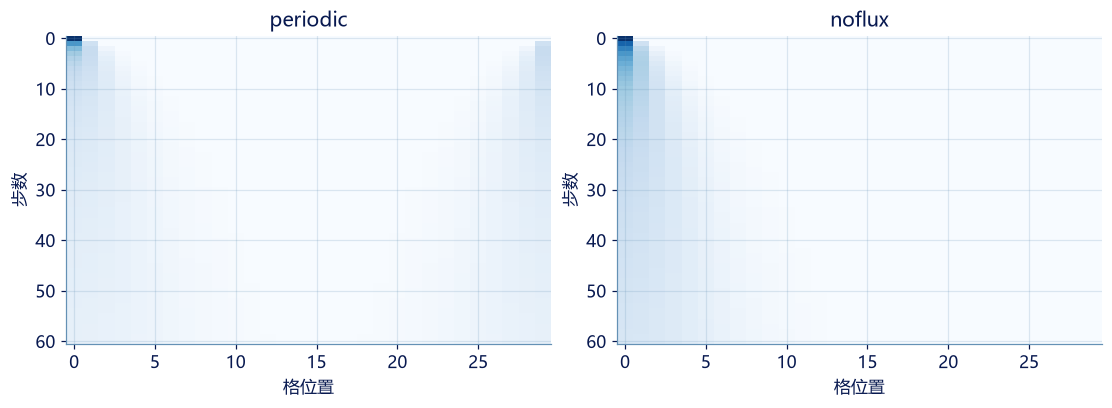

过大步长后 [2.0, -2.0, 2.0] ；总和 2.0


In [4]:
initial=[2.]+[0.]*29;good={}
for boundary in ['periodic','noflux']:
    good[boundary]=np.array(diffuse_1d(initial,1.,1.,.2,60,boundary))
bad=np.array(diffuse_1d([0.,2.,0.],1.,1.,1.,1,'periodic'))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,(name,trajectory) in zip(axes,good.items()):
    ax.imshow(trajectory,aspect='auto',cmap='Blues')
    ax.set(xlabel='格位置',ylabel='步数',title=name)
plt.show()
print('过大步长后',bad[-1].tolist(),'；总和',bad[-1].sum())

## 结果解释

周期图有跨边界通道，无通量端点则没有；两图总和相同却局部轨迹（trajectory）不同。过大步长反例守恒而负值，证明守恒检查（conservation check）不能替代物理合理性与网格细化。

### 独立核对

独立核对三格手算、逐步质量和、非负性（nonnegativity）以及失稳反例。

In [5]:
np.testing.assert_allclose(diffuse_1d([0.,2.,0.],1.,1.,.25,1,'periodic')[-1],[.5,1.,.5])
for path in good.values():
    np.testing.assert_allclose(path.sum(axis=1),2.,atol=1e-10)
    assert path.min()>=-1e-12
assert bad.min()<0 and abs(bad[-1].sum()-2)<1e-12
print('边界、守恒、非负与坏步长反例通过。')

边界、守恒、非负与坏步长反例通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一维网格上的纯扩散

无反应一维等距网格，使用显式更新 x_i^+=x_i+D·dt/dx²·(x_left−2x_i+x_right)。periodic 两端相连；noflux 使用单元中心守恒离散，端点没有跨界通量；代码等价于越界邻居取端点自身。返回含初态的所有网格行。

**函数与代码模板**

```python
def solve(
    values: list[float],
    diffusivity: float,
    dx: float,
    dt: float,
    steps: int,
    boundary: str,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 非负网格初值（initial condition），至少3格。 | U/格 |
| `diffusivity` | `float` | 扩散系数（diffusion coefficient），非负。 | 格长²/T |
| `dx` | `float` | 网格间距，正数。 | 格长 |
| `dt` | `float` | 时间步，正数。 | T |
| `steps` | `int` | 更新步数。 | 步 |
| `boundary` | `str` | periodic 或 noflux。 | 类别 |

**返回值**

直接返回 history（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 含初值的网格状态（state）。 | U/格 |

**计算规则**

使用旧行同时更新；题定 D·dt/dx²≤1/2，纯扩散的总和保持不变。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 非负网格初值（initial condition），至少3格。 | [1.0, 0.0, 0.0, 0.0] | U/格 |
| diffusivity | 扩散系数（diffusion coefficient），非负。 | 1 | 格长²/T |
| dx | 网格间距，正数。 | 1 | 格长 |
| dt | 时间步，正数。 | 0.25 | T |
| steps | 更新步数。 | 2 | 步 |
| boundary | periodic 或 noflux。 | periodic | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [1.0, 0.0, 0.0, 0.0]
diffusivity = 1.0
dx = 1.0
dt = 0.25
steps = 2
boundary = 'periodic'

result = solve(values, diffusivity, dx, dt, steps, boundary)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 含初值的网格状态（state）。 | [[1.0, 0.0, 0.0, 0.0], [0.5, 0.25, 0.0, 0.25], [0.375, 0.25, 0.125, 0.25]] | U/格 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1.0, 0.0, 0.0, 0.0],
                   [0.5, 0.25, 0.0, 0.25],
                   [0.375, 0.25, 0.125, 0.25]]
```

**样例解释**

周期边界（periodic boundary）的单脉冲向两端扩散；无通量端点无跨界通道。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一维网格上的纯扩散](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-diffusion-grid)

### 第 2 题 · 单项选择题：显式步长条件

本节一维纯扩散、均匀 dx、内点中心差分（central difference）、端点守恒无通量处理的显式格式，令 α=D·dt/dx²。哪个条件保证系数非负并给出本格式的稳定范围？

- **A.** 0≤α≤1/2。
- **B.** α>1。
- **C.** 任意 dt 都行。
- **D.** 只要求 D≥0。

[作答：显式步长条件](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-diffusion-cfl)

### 第 3 题 · 单项选择题：无通量端点

左端 noflux 条件在本节单元中心守恒离散规则下如何处理越界左邻格？

- **A.** 取左端格自身。
- **B.** 取最右格。
- **C.** 固定为负一。
- **D.** 忽略左端更新。

[作答：无通量端点](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-noflux-end)

### 第 4 题 · 单项选择题：总和守恒就可信？

一维纯扩散显式程序保留总和，但某格出现负数。下一步应怎样判断？

- **A.** 检查步长、非负性（nonnegativity）和网格收敛，不能只看守恒。
- **B.** 守恒已证明物理正确。
- **C.** 负值代表真实反向物质。
- **D.** 删去负格并保持原结果。

[作答：总和守恒就可信？](http://127.0.0.1:8000/chapters/12-04-%E7%A9%BA%E9%97%B4%E8%87%AA%E7%BB%84%E7%BB%87%E4%B8%8E%E5%8F%8D%E5%BA%94%E6%89%A9%E6%95%A3/practice/?question=p12-mass-not-enough)

**进一步阅读**

[Turing 原始论文](https://doi.org/10.1098/rstb.1952.0012)引出空间反应问题；本节先单独验证扩散离散。